**Version 1**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, UpSampling2D, Input, Concatenate, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanAbsoluteError
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Load  data
grayscale_path = "/content/drive/My Drive/dataset/gray/gray_scale.npy"
ab_dir = "/content/drive/My Drive/dataset/ab/ab"


In [3]:
grayscale_images = np.load(grayscale_path)
ab_files = [os.path.join(ab_dir, f"ab{i}.npy") for i in range(1, 4)]
ab_images = np.concatenate([np.load(file) for file in ab_files], axis=0)

# Subset for faster experimentation
grayscale_images = grayscale_images[:15000]
ab_images = ab_images[:15000]

# Normalize data
grayscale_images = grayscale_images / 255.0  # Normalize grayscale to [0, 1]
ab_images = (ab_images - 128) / 128.0  # Normalize AB channels to [-1, 1]

# Add channel dimension to grayscale images
grayscale_images = grayscale_images[..., np.newaxis]

# Split into train and validation sets
x_train, x_val, y_train, y_val = train_test_split(grayscale_images, ab_images, test_size=0.2, random_state=42)

In [4]:
def create_unet_model(input_shape=(224, 224, 1)):
    inputs = Input(shape=input_shape)

    # Encoder
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)

    # Decoder
    u1 = UpSampling2D((2, 2))(c3)
    concat1 = Concatenate()([u1, c2])
    c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(concat1)

    u2 = UpSampling2D((2, 2))(c4)
    concat2 = Concatenate()([u2, c1])
    c5 = Conv2D(64, (3, 3), activation='relu', padding='same')(concat2)

    outputs = Conv2D(2, (3, 3), activation='tanh', padding='same')(c5)  # AB channel output
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss=MeanAbsoluteError())
    return model

# Create and train the model
model = create_unet_model(input_shape=(x_train.shape[1], x_train.shape[2], x_train.shape[3]))

# Data augmentation
datagen = ImageDataGenerator(
    brightness_range=[0.8, 1.2],
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator = datagen.flow(x_train, y_train, batch_size=32)

# Train model
history = model.fit(
    train_generator,
    validation_data=(x_val, y_val),
    epochs=20,
    callbacks=[EarlyStopping(patience=3)]
)

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


375/375 ━━━━━━━━━━━━━━━━━━━━ 78s 150ms/step - loss: 0.5683 - val_loss: 0.5782
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 50s 130ms/step - loss: 0.5684 - val_loss: 0.5769
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 49s 128ms/step - loss: 0.5685 - val_loss: 0.5750
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 49s 129ms/step - loss: 0.5690 - val_loss: 0.5764
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 49s 129ms/step - loss: 0.5667 - val_loss: 0.5748
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 50s 130ms/step - loss: 0.5604 - val_loss: 0.5763
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 50s 131ms/step - loss: 0.5718 - val_loss: 0.5743
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 50s 131ms/step - loss: 0.5643 - val_loss: 0.5734
Epoch 9/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 51s 134ms/step - loss: 0.5693 - val_loss: 0.5765
Epoch 10/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 50s 130ms/step - loss: 0.5730 - val_loss: 0.5679
Epoch 11/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 51s 133ms/step - loss: 0.5685 - val_loss: 0.5689
Epoch 12/20
375/375 ━━━━━━━━━━

In [5]:
def lab_to_rgb(grayscale_input, ab_pred):
    lab_image = np.zeros((grayscale_input.shape[0], grayscale_input.shape[1], 3))
    lab_image[:, :, 0] = grayscale_input[:, :, 0] * 100  # Rescale L to [0, 100]
    lab_image[:, :, 1:] = ab_pred * 128  # Rescale AB to [-128, 127]
    rgb_image = cv2.cvtColor(lab_image.astype('float32'), cv2.COLOR_LAB2RGB)
    return np.clip(rgb_image, 0, 1)  # Clip values to valid range

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


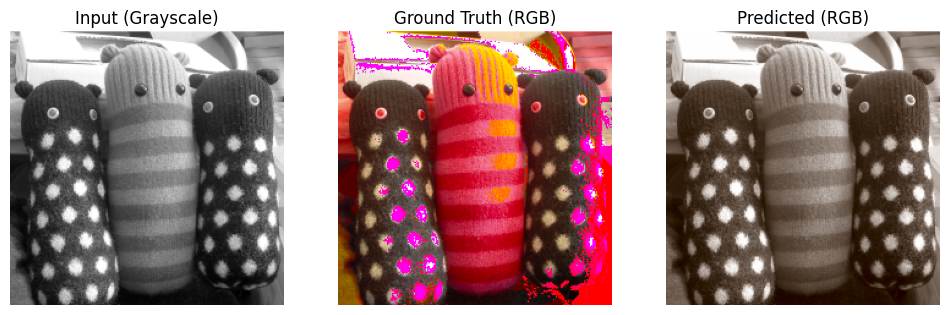

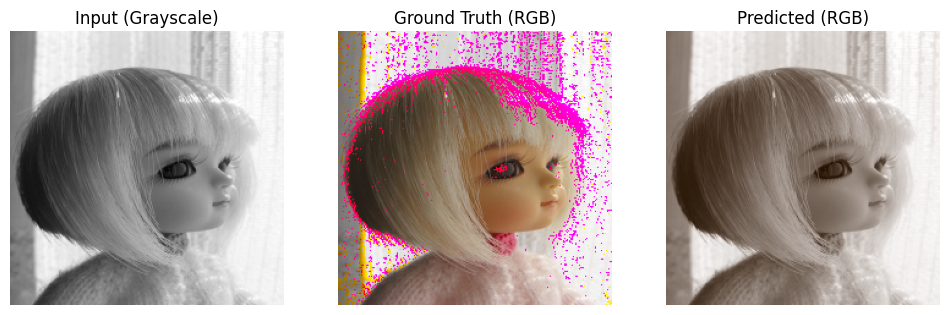

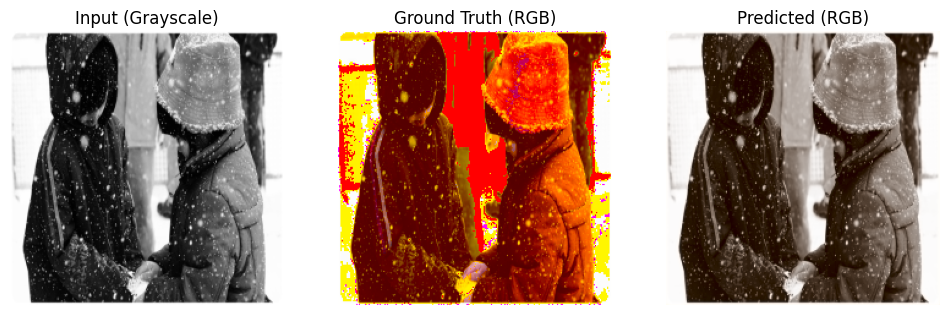

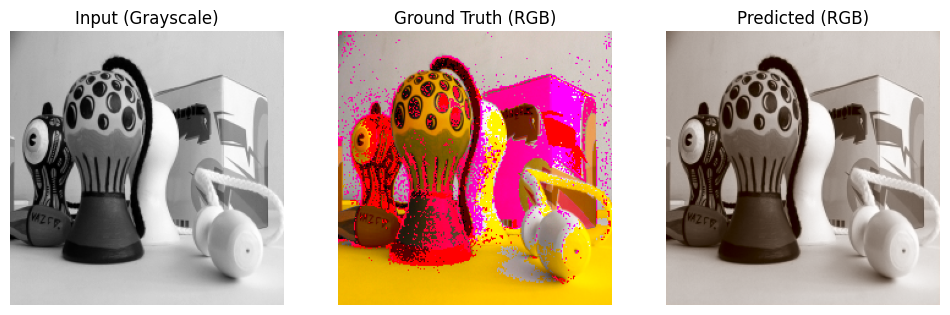

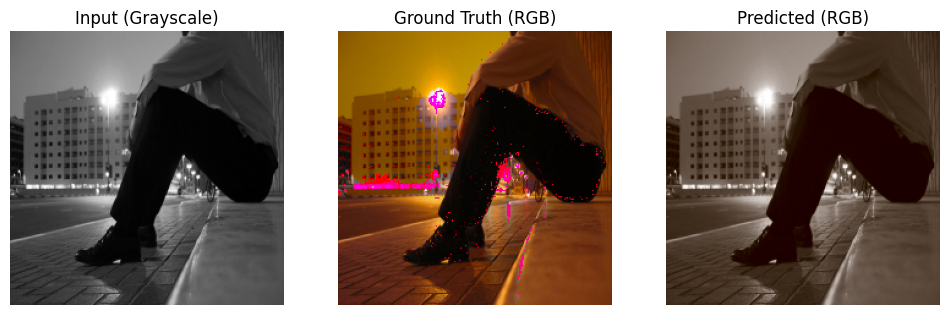

In [6]:
def visualize_predictions(grayscale_input, ground_truth_ab, model):
    predictions = model.predict(grayscale_input)
    for i in range(5):  # Show two examples
        gray = grayscale_input[i].squeeze()  # (224, 224)
        ab_true = ground_truth_ab[i]  # (224, 224, 2)
        ab_pred = predictions[i]  # (224, 224, 2)

        # Ground Truth LAB to RGB
        rgb_true = lab_to_rgb(np.expand_dims(gray, axis=-1), ab_true)

        # Predicted LAB to RGB
        rgb_pred = lab_to_rgb(np.expand_dims(gray, axis=-1), ab_pred)

        # Plot results
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.title("Input (Grayscale)")
        plt.imshow(gray, cmap='gray')
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title("Ground Truth (RGB)")
        plt.imshow(rgb_true)
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title("Predicted (RGB)")
        plt.imshow(rgb_pred)
        plt.axis('off')
        plt.show()

# Visualize predictions
visualize_predictions(x_val, y_val, model)

**Version 2**

In [7]:
grayscale_images = np.load(grayscale_path)
ab_files = [os.path.join(ab_dir, f"ab{i}.npy") for i in range(1, 4)]
ab_images = np.concatenate([np.load(file) for file in ab_files], axis=0)

# Subset for faster experimentation
grayscale_images = grayscale_images[:10000]
ab_images = ab_images[:10000]

# Normalize data
grayscale_images = grayscale_images / 255.0  # Normalize grayscale to [0, 1]
ab_images = (ab_images - 128) / 128.0  # Normalize AB channels to [-1, 1]

# Add channel dimension to grayscale images
grayscale_images = grayscale_images[..., np.newaxis]

# Split into train and validation sets
x_train, x_val, y_train, y_val = train_test_split(grayscale_images, ab_images, test_size=0.2, random_state=42)

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer

# Model architecture
def create_colorization_model(input_shape=(224, 224, 1)):
    model = Sequential([
        InputLayer(input_shape=input_shape),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        Conv2D(128, (3, 3), activation='relu', padding='same', strides=2),  # Downsample
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        Conv2D(256, (3, 3), activation='relu', padding='same', strides=2),  # Downsample
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        UpSampling2D((2, 2)),  # Upsample
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        UpSampling2D((2, 2)),  # Upsample
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        Conv2D(2, (3, 3), activation='tanh', padding='same')  # AB channel output
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss=MeanAbsoluteError())
    return model

# Create and train the model
model = create_colorization_model(input_shape=(x_train.shape[1], x_train.shape[2], x_train.shape[3]))

# Data augmentation
datagen = ImageDataGenerator(
    brightness_range=[0.8, 1.2],
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow(x_train, y_train, batch_size=32)

# Train model
history = model.fit(
    train_generator,
    validation_data=(x_val, y_val),
    epochs=10,
    callbacks=[EarlyStopping(patience=3)]
)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 57s 154ms/step - loss: 0.5624 - val_loss: 0.5862
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 129ms/step - loss: 0.5639 - val_loss: 0.5819
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 129ms/step - loss: 0.5613 - val_loss: 0.5882
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 130ms/step - loss: 0.5654 - val_loss: 0.5862
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 129ms/step - loss: 0.5621 - val_loss: 0.5839


In [9]:
# Function to convert LAB to RGB
def lab_to_rgb(grayscale_input, ab_pred):
    lab_image = np.zeros((grayscale_input.shape[0], grayscale_input.shape[1], 3))
    lab_image[:, :, 0] = grayscale_input[:, :, 0] * 100  # Rescale L to [0, 100]
    lab_image[:, :, 1:] = ab_pred * 128  # Rescale AB to [-128, 127]
    rgb_image = cv2.cvtColor(lab_image.astype('float32'), cv2.COLOR_LAB2RGB)
    return np.clip(rgb_image, 0, 1)  # Clip values to valid range

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


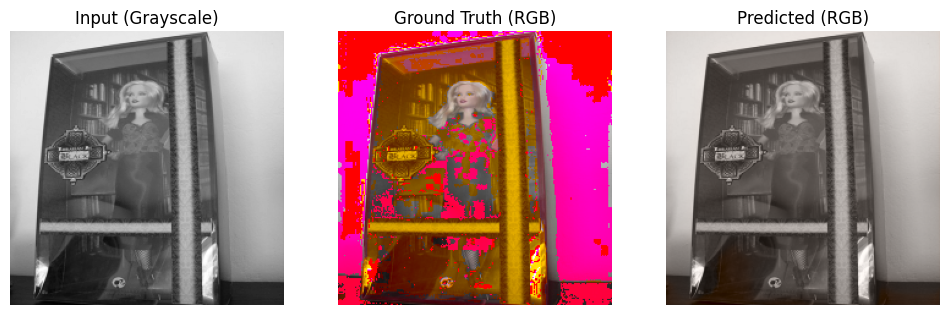

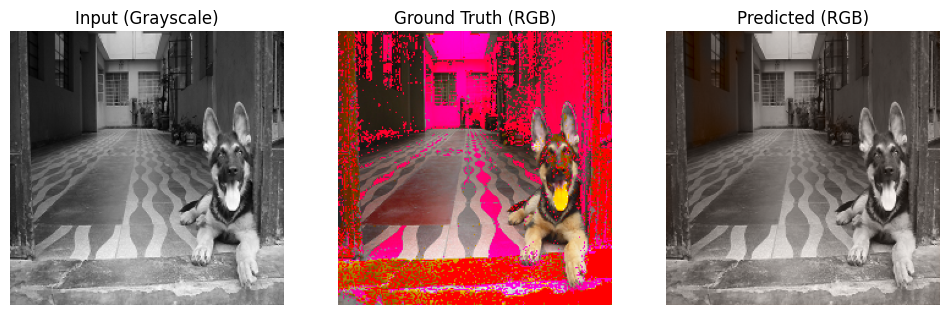

In [10]:
# Visualization of predictions
def visualize_predictions(grayscale_input, ground_truth_ab, model):
    predictions = model.predict(grayscale_input)
    for i in range(2):  # Show two examples
        gray = grayscale_input[i].squeeze()  # (224, 224)
        ab_true = ground_truth_ab[i]  # (224, 224, 2)
        ab_pred = predictions[i]  # (224, 224, 2)

        # Ground Truth LAB to RGB
        rgb_true = lab_to_rgb(np.expand_dims(gray, axis=-1), ab_true)

        # Predicted LAB to RGB
        rgb_pred = lab_to_rgb(np.expand_dims(gray, axis=-1), ab_pred)

        # Plot results
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.title("Input (Grayscale)")
        plt.imshow(gray, cmap='gray')
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title("Ground Truth (RGB)")
        plt.imshow(rgb_true)
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title("Predicted (RGB)")
        plt.imshow(rgb_pred)
        plt.axis('off')
        plt.show()

# Visualize predictions
visualize_predictions(x_val, y_val, model)